# Test autorskiej architektury CNN

Celem eksperymentu jest ocena autorskiej architektury konwolucyjnej CNN opracowanej na potrzeby klasyfikacji polskich znaków drogowych.

W przeciwieństwie do modeli wykorzystujących transfer learning, autorska sieć CNN jest trenowana od podstaw. Eksperyment ma określić, czy zaprojektowana architektura zapewnia lepszą skuteczność klasyfikacji od modelu Resnet50.

W eksperymencie zachowano wcześniej ustalone elementy pipeline'u:

- podział danych,
- `WeightedRandomSampler`,
- augmentację oświetleniową,
- korekcję gamma γ = 1.5,
- funkcję straty Cross Entropy.

Zbiór `test_final` nie jest wykorzystywany.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image


PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.sampling import (
    build_weighted_sampler,
)

from src.data.preprocessing import (
    gamma_correction,
    build_preprocessing_train_transform,
    build_preprocessing_eval_transform,
)

from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_FACTORS,
    RandomLightingAugmentation,
)

from src.models.custom_cnn import (
    create_custom_cnn,
)

from src.training.trainer import (
    fit,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)

HISTORIES_DIR = (
    RESULTS_DIR
    / "histories"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "custom_cnn_screening"
)

FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)


for directory in [
    METRICS_DIR,
    HISTORIES_DIR,
    CHECKPOINT_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Urządzenie:",
    DEVICE
)

Urządzenie: cpu


## 1. Konfiguracja eksperymentu

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 20 #7
LEARNING_RATE = 1e-3
RANDOM_SEED = 42
PREPROCESSING_METHOD = "gamma"
GAMMA_VALUE = 1.5

LIGHTING_BRIGHTNESS_RANGE = (
    0.3,
    1.3,
)

LIGHTING_CONTRAST_RANGE = (
    0.8,
    1.2,
)

LIGHTING_PROBABILITY = 0.8


DARK_VARIANTS = [
    "dark_1",
    "dark_2",
    "dark_3",
]


print(
    "Rozdzielczość:",
    IMAGE_SIZE,
)

print(
    "Batch size:",
    BATCH_SIZE,
)

print(
    "Liczba epok:",
    EPOCHS,
)

print(
    "Learning rate:",
    LEARNING_RATE,
)

print(
    "Preprocessing:",
    PREPROCESSING_METHOD,
)

print(
    "Gamma:",
    GAMMA_VALUE,
)

print(
    "Zakres jasności:",
    LIGHTING_BRIGHTNESS_RANGE,
)

print(
    "Zakres kontrastu:",
    LIGHTING_CONTRAST_RANGE,
)

print(
    "Prawdopodobieństwo augmentacji:",
    LIGHTING_PROBABILITY,
)

Rozdzielczość: 224
Batch size: 32
Liczba epok: 20
Learning rate: 0.001
Preprocessing: gamma
Gamma: 1.5
Zakres jasności: (0.3, 1.3)
Zakres kontrastu: (0.8, 1.2)
Prawdopodobieństwo augmentacji: 0.8


## 2. Manifesty danych i mapowanie klas

In [3]:
TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)

VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)

TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

print(
    "TRAIN:",
    len(train_df)
)

print(
    "VALIDATION:",
    len(validation_df)
)

print(
    "TEST_FINAL:",
    len(test_df)
)

Liczba klas: 92
TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


## 3. Transformacje treningowe

W eksperymencie wykorzystano wybraną wcześniej konfigurację augmentacji oświetleniowej `lighting_strong_dark`, obejmującą zmianę jasności w zakresie 0.3–1.3 oraz zmianę kontrastu w zakresie 0.8–1.2 z prawdopodobieństwem 0.8.

Po augmentacji zastosowano korekcję gamma γ = 1.5.

Pozostałe operacje przygotowania obrazu są realizowane przez istniejące funkcje preprocessingu projektu.

In [4]:
normalization = transforms.Normalize(
    mean=(
        0.485,
        0.456,
        0.406,
    ),
    std=(
        0.229,
        0.224,
        0.225,
    ),
)


preprocessor = (
    lambda image:
    build_preprocessing_train_transform(
        method=PREPROCESSING_METHOD,
        image_size=IMAGE_SIZE,
        gamma=GAMMA_VALUE,
    )(image)
)

In [5]:
base_train_transform = (
    build_preprocessing_train_transform(
        method=PREPROCESSING_METHOD,
        image_size=IMAGE_SIZE,
        gamma=GAMMA_VALUE,
    )
)


eval_transform = (
    build_preprocessing_eval_transform(
        method=PREPROCESSING_METHOD,
        image_size=IMAGE_SIZE,
        gamma=GAMMA_VALUE,
    )
)


lighting_augmentation = (
    RandomLightingAugmentation(
        brightness_range=(
            *LIGHTING_BRIGHTNESS_RANGE,
        ),

        contrast_range=(
            *LIGHTING_CONTRAST_RANGE,
        ),

        probability=LIGHTING_PROBABILITY,
    )
)


train_transform = transforms.Compose([
    lighting_augmentation,
    base_train_transform,
])

## 4. Kontrola wizualna transformacji treningowych

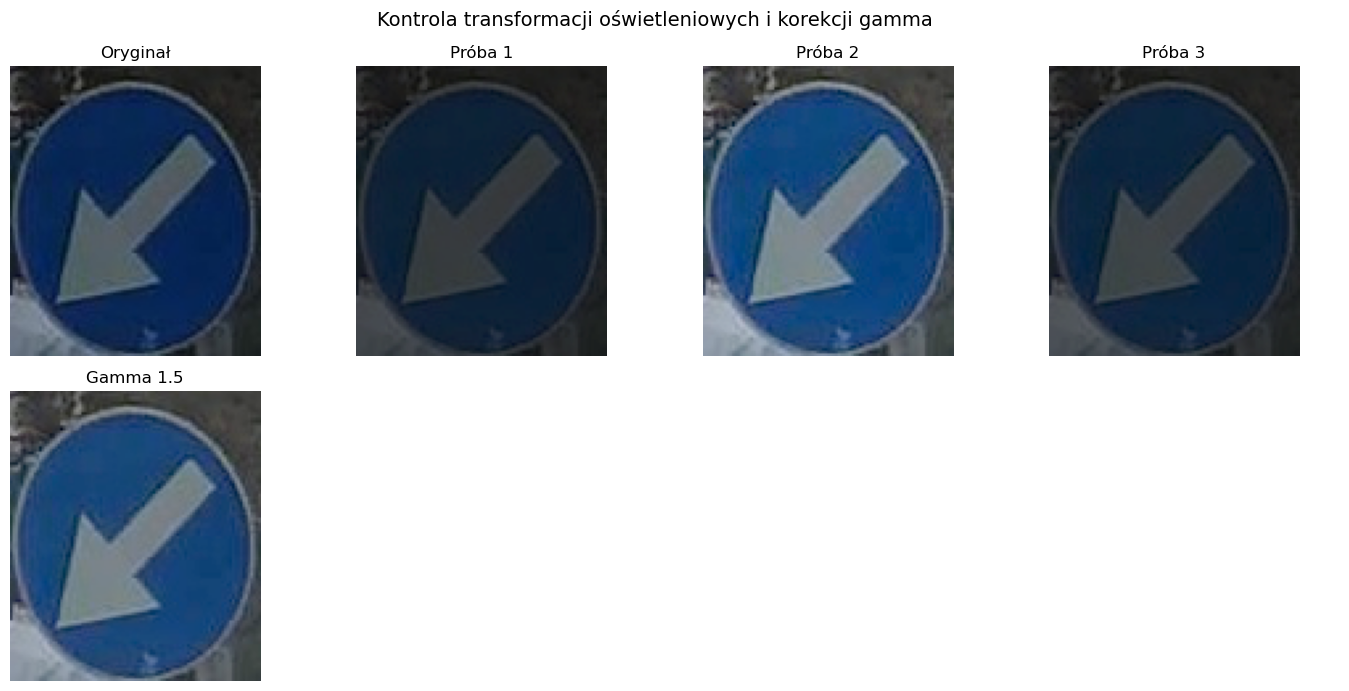

In [6]:
from src.data.preprocessing import (
    gamma_correction,
    build_preprocessing_train_transform,
    build_preprocessing_eval_transform,
)

sample_path = Path(
    train_df.iloc[0][
        "path"
    ]
)


sample_image = Image.open(
    sample_path
).convert("RGB")


fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7),
)


axes[0, 0].imshow(
    sample_image
)

axes[0, 0].set_title(
    "Oryginał"
)

axes[0, 0].axis(
    "off"
)


for col_index in range(1, 4):

    transformed = (
        RandomLightingAugmentation(
            brightness_range=(
                *LIGHTING_BRIGHTNESS_RANGE,
            ),

            contrast_range=(
                *LIGHTING_CONTRAST_RANGE,
            ),

            probability=1.0,
        )
    )(
        sample_image
    )

    transformed = (
        gamma_correction(
            transformed,
            gamma=GAMMA_VALUE,
        )
        if PREPROCESSING_METHOD == "gamma"
        else transformed
    )


    axes[0, col_index].imshow(
        transformed
    )

    axes[0, col_index].set_title(
        f"Próba {col_index}"
    )

    axes[0, col_index].axis(
        "off"
    )


axes[1, 0].imshow(
    gamma_correction(
        sample_image,
        gamma=GAMMA_VALUE,
    )
)

axes[1, 0].set_title(
    "Gamma 1.5"
)

axes[1, 0].axis(
    "off"
)


for col_index in range(1, 4):
    axes[1, col_index].axis(
        "off"
    )


fig.suptitle(
    "Kontrola transformacji "
    "oświetleniowych i korekcji gamma",
    fontsize=14,
)


plt.tight_layout()
plt.show()

## 5. Przygotowanie DataLoaderów

In [7]:
train_dataset = TrafficSignDataset(
    TRAIN_PATH,
    class_to_idx,
    transform=train_transform,
)


validation_dataset = TrafficSignDataset(
    VALIDATION_PATH,
    class_to_idx,
    transform=eval_transform,
)


weighted_sampler = (
    build_weighted_sampler(
        TRAIN_PATH
    )
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)


validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)


print(
    "Liczba próbek treningowych:",
    len(train_dataset)
)

print(
    "Liczba próbek walidacyjnych:",
    len(validation_dataset)
)

Liczba próbek treningowych: 14232
Liczba próbek walidacyjnych: 2512


## 6. Autorska architektura CNN

Autorska sieć CNN jest zbudowana z czterech warstw konwolucyjnych o liczbie filtrów odpowiednio 32, 64, 128 i 256. Po warstwach konwolucyjnych zastosowano Batch Normalization oraz funkcję aktywacji ReLU. W pierwszych trzech blokach wykorzystano operację Max Pooling.

Po części konwolucyjnej zastosowano Adaptive Average Pooling. Klasyfikator składa się z warstwy Dropout oraz końcowej warstwy liniowej przypisującej obraz do jednej z 92 klas.

In [8]:
model = create_custom_cnn(
    num_classes=len(
        class_codes
    )
)


model = model.to(
    DEVICE
)


total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)


trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


print(
    model
)

print(
    "\nLiczba wszystkich parametrów:",
    f"{total_params:,}"
)

print(
    "Liczba trenowalnych parametrów:",
    f"{trainable_params:,}"
)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

## 7. Trening autorskiej sieci CNN

Zastosowano funkcję straty Cross Entropy oraz optymalizator Adam ze współczynnikiem uczenia równym 0.001.

Najlepszy stan modelu jest wybierany na podstawie walidacyjnego `Macro F1`.

In [9]:
set_seed(
    RANDOM_SEED
)


model = create_custom_cnn(
    num_classes=len(
        class_codes
    )
).to(
    DEVICE
)


criterion = (
    nn.CrossEntropyLoss()
)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)


checkpoint_path = (
    CHECKPOINT_DIR
    / "custom_cnn_screening.pt"
)


history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=EPOCHS,
    checkpoint_path=checkpoint_path,
)


print(
    "\nTrening zakończony."
)

print(
    "Najlepszy Validation Macro F1:",
    f"{history['best_val_macro_f1']:.6f}",
)

print(
    "Czas treningu [s]:",
    f"{history['training_time_seconds']:.2f}",
)

Postęp treningu:   0%|          | 0/20 [00:00<?, ?it/s]

Epoka 1/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/20:   0%|          | 0/445 [00:00<?, ?it/s]

...

Epoka 17/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 18/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 19/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 20/20:   0%|          | 0/445 [00:00<?, ?it/s]


Trening zakończony.
Najlepszy Validation Macro F1: 0.854669
Czas treningu [s]: 16580.49


## 8. Historia treningu

In [10]:
history_df = pd.DataFrame({
    "train_loss":
        history["train_loss"],

    "train_accuracy":
        history["train_accuracy"],

    "val_loss":
        history["val_loss"],

    "val_accuracy":
        history["val_accuracy"],

    "val_macro_f1":
        history["val_macro_f1"],
})


history_path = (
    HISTORIES_DIR
    / "custom_cnn_screening_history.csv"
)


history_df.to_csv(
    history_path,
    index=False,
    encoding="utf-8-sig",
)


display(
    history_df
)

,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1
0,3.343518,0.125281,2.996425,0.175557,0.114118
1,2.805817,0.213884,2.795756,0.191481,0.135448
2,2.490166,0.297780,2.443017,0.266322,0.280624
3,2.117801,0.402684,2.089217,0.355892,0.328149
4,1.779399,0.493184,1.717117,0.482484,0.453964
5,1.490211,0.569351,1.306986,0.637739,0.553622
6,1.334308,0.610315,1.227622,0.624602,0.555671
7,1.163188,0.657813,1.088203,0.706210,0.615707
8,1.050424,0.693578,1.027235,0.693471,0.670946
9,0.945225,0.719013,0.971222,0.693471,0.632881


## 9. Wizualizacja procesu uczenia

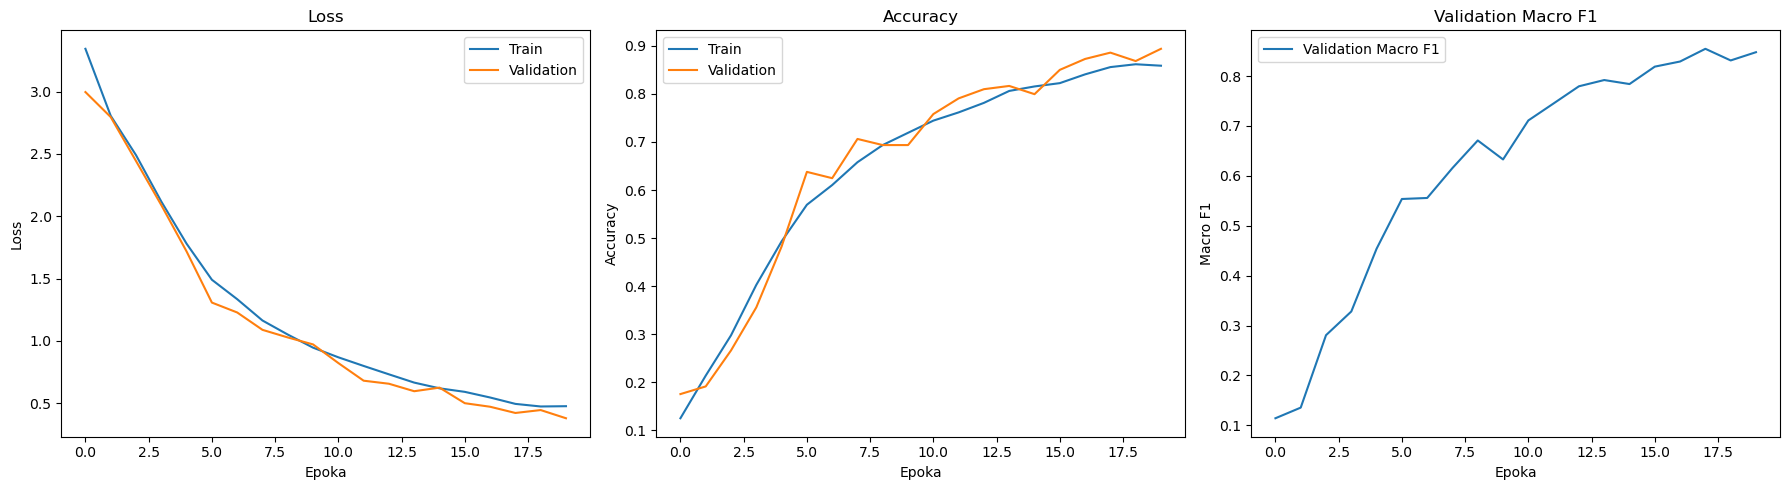

In [11]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


axes[0].plot(
    history_df[
        "train_loss"
    ],
    label="Train",
)

axes[0].plot(
    history_df[
        "val_loss"
    ],
    label="Validation",
)

axes[0].set_title(
    "Loss"
)

axes[0].set_xlabel(
    "Epoka"
)

axes[0].set_ylabel(
    "Loss"
)

axes[0].legend()


axes[1].plot(
    history_df[
        "train_accuracy"
    ],
    label="Train",
)

axes[1].plot(
    history_df[
        "val_accuracy"
    ],
    label="Validation",
)

axes[1].set_title(
    "Accuracy"
)

axes[1].set_xlabel(
    "Epoka"
)

axes[1].set_ylabel(
    "Accuracy"
)

axes[1].legend()


axes[2].plot(
    history_df[
        "val_macro_f1"
    ],
    label="Validation Macro F1",
)

axes[2].set_title(
    "Validation Macro F1"
)

axes[2].set_xlabel(
    "Epoka"
)

axes[2].set_ylabel(
    "Macro F1"
)

axes[2].legend()


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_custom_cnn_training_history.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 10. Standardowa skuteczność na zbiorze walidacyjnym

Po zakończeniu treningu model oceniono na zbiorze walidacyjnym.

Analizie poddano Accuracy, Macro Precision, Macro Recall oraz Macro F1.

In [12]:
y_val_true, y_val_pred, validation_inference_time = (
    predict(
        model,
        validation_loader,
        DEVICE,
    )
)


validation_metrics = (
    evaluate_predictions(
        y_val_true,
        y_val_pred,
    )
)


standard_validation = {
    "model":
        "CustomCNN",

    "accuracy":
        validation_metrics[
            "accuracy"
        ],

    "macro_precision":
        validation_metrics[
            "macro_precision"
        ],

    "macro_recall":
        validation_metrics[
            "macro_recall"
        ],

    "macro_f1":
        validation_metrics[
            "macro_f1"
        ],

    "training_time_seconds":
        history[
            "training_time_seconds"
        ],

    "inference_time_seconds":
        validation_inference_time,

    "parameters":
        total_params,
}


standard_validation_df = (
    pd.DataFrame(
        [standard_validation]
    )
)


display(
    standard_validation_df
)


standard_validation_df.to_csv(
    METRICS_DIR
    / "custom_cnn_screening_standard_validation.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,accuracy,macro_precision,macro_recall,macro_f1,training_time_seconds,inference_time_seconds,parameters
0,CustomCNN,0.885748,0.855705,0.897944,0.854669,16580.48755,50.272998,413020


## 11. Raport klasyfikacji

In [13]:
classification_report_df = (
    pd.DataFrame(
        validation_metrics[
            "classification_report"
        ]
    ).T
)


classification_report_df.to_csv(
    METRICS_DIR
    / "custom_cnn_screening_classification_report.csv",
    encoding="utf-8-sig",
)


display(
    classification_report_df
)

,precision,recall,f1-score,support
0,0.896552,0.896552,0.896552,29.000000
1,1.000000,0.833333,0.909091,6.000000
2,0.555556,1.000000,0.714286,5.000000
3,0.818182,0.750000,0.782609,12.000000
4,1.000000,0.833333,0.909091,6.000000
...,...,...,...,...
90,1.000000,1.000000,1.000000,6.000000
91,1.000000,1.000000,1.000000,3.000000
accuracy,0.885748,0.885748,0.885748,0.885748
macro avg,0.855705,0.897944,0.854669,2512.000000


## 12. Macierz pomyłek

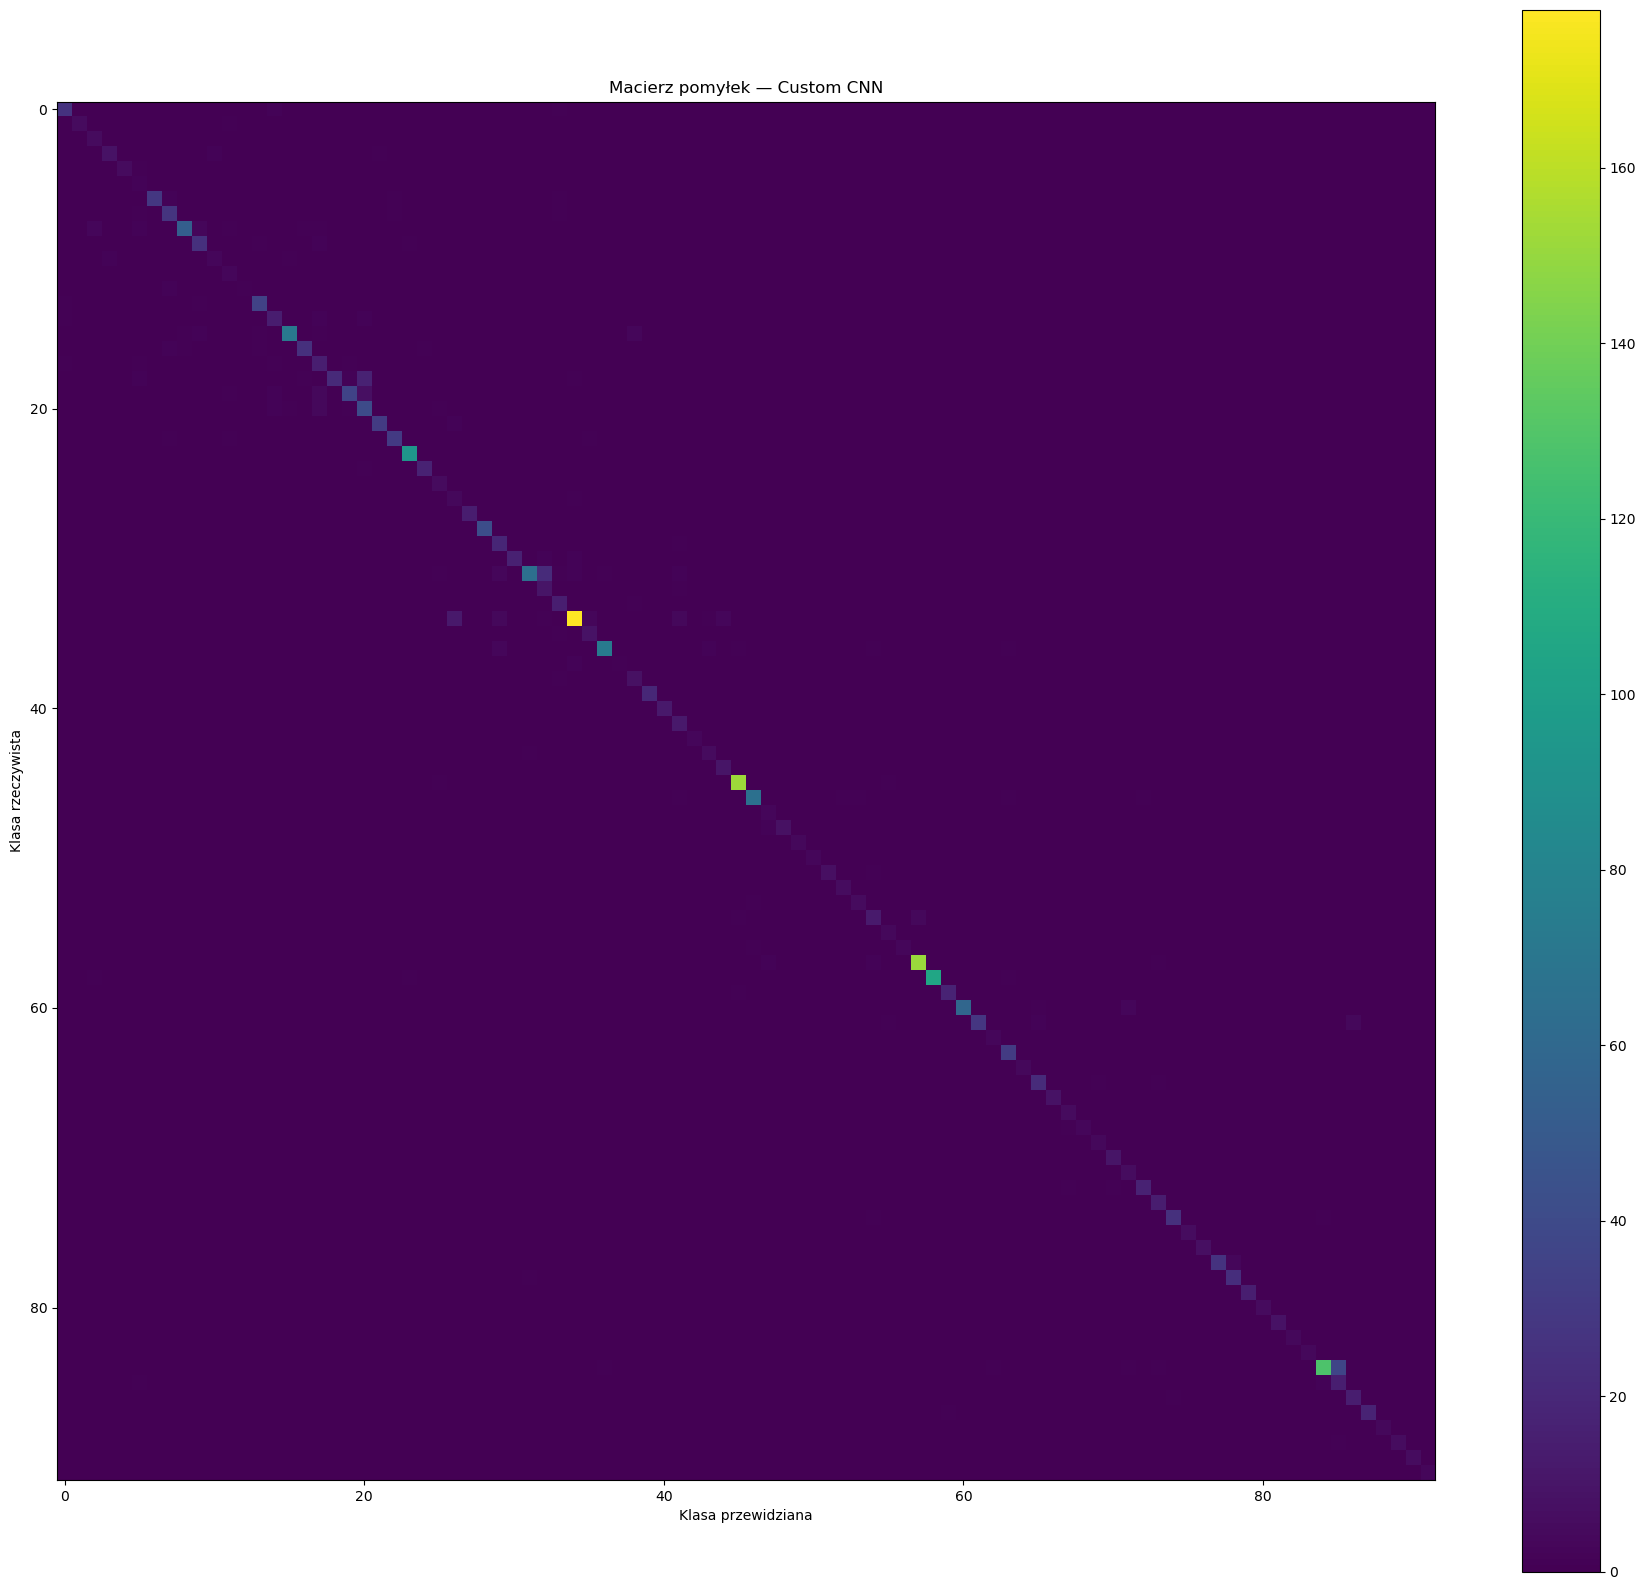

In [14]:
cm = (
    validation_metrics[
        "confusion_matrix"
    ]
)


fig, ax = plt.subplots(
    figsize=(18, 16)
)


im = ax.imshow(
    cm
)


ax.set_title(
    "Macierz pomyłek — Custom CNN"
)

ax.set_xlabel(
    "Klasa przewidziana"
)

ax.set_ylabel(
    "Klasa rzeczywista"
)


fig.colorbar(
    im,
    ax=ax,
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "02_custom_cnn_confusion_matrix.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 13. Funkcja oceny kontrolowanego zaciemnienia

W celu oceny odporności modelu na zmienne warunki oświetleniowe wykorzystano kontrolowane warianty zaciemnienia `dark_1`, `dark_2` i `dark_3`.

In [15]:
def evaluate_lighting_variant(
    model,
    variant,
):

    dataset = (
        ControlledLightingDataset(
            VALIDATION_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=eval_transform,
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = (
        evaluate_predictions(
            y_true,
            y_pred,
        )
    )


    return {
        "samples":
            len(dataset),

        "accuracy":
            metrics[
                "accuracy"
            ],

        "macro_precision":
            metrics[
                "macro_precision"
            ],

        "macro_recall":
            metrics[
                "macro_recall"
            ],

        "macro_f1":
            metrics[
                "macro_f1"
            ],

        "inference_time_seconds":
            inference_time,
    }

## 14. Ocena odporności na zaciemnienie

In [16]:
dark_results = []


for variant in DARK_VARIANTS:

    print(
        f"CustomCNN | {variant}"
    )


    metrics = (
        evaluate_lighting_variant(
            model=model,
            variant=variant,
        )
    )


    dark_results.append(
        {
            "variant":
                variant,

            "factor":
                LIGHTING_FACTORS[
                    variant
                ],

            **metrics,
        }
    )


dark_results_df = (
    pd.DataFrame(
        dark_results
    )
)


display(
    dark_results_df
)


dark_results_df.to_csv(
    METRICS_DIR
    / "custom_cnn_screening_dark_results.csv",
    index=False,
    encoding="utf-8-sig",
)

CustomCNN | dark_1
CustomCNN | dark_2
CustomCNN | dark_3


,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,dark_1,0.7,2512,0.885350,0.858532,0.898592,0.856199,52.607543
1,dark_2,0.5,2512,0.855096,0.822038,0.873717,0.820290,49.934942
2,dark_3,0.3,2512,0.796975,0.779610,0.808699,0.754517,50.282948


## 15. Podsumowanie odporności

In [17]:
mean_dark_macro_f1 = (
    dark_results_df[
        "macro_f1"
    ].mean()
)


mean_dark_accuracy = (
    dark_results_df[
        "accuracy"
    ].mean()
)


dark3_macro_f1 = (
    dark_results_df.loc[
        dark_results_df[
            "variant"
        ] == "dark_3",
        "macro_f1",
    ].iloc[0]
)


standard_macro_f1 = (
    standard_validation[
        "macro_f1"
    ]
)


f1_drop_to_dark3 = (
    standard_macro_f1
    -
    dark3_macro_f1
)


robustness_summary = pd.DataFrame([
    {
        "model":
            "CustomCNN",

        "standard_macro_f1":
            standard_macro_f1,

        "mean_dark_macro_f1":
            mean_dark_macro_f1,

        "mean_dark_accuracy":
            mean_dark_accuracy,

        "dark3_macro_f1":
            dark3_macro_f1,

        "f1_drop_to_dark3":
            f1_drop_to_dark3,
    }
])


display(
    robustness_summary
)


robustness_summary.to_csv(
    METRICS_DIR
    / "custom_cnn_screening_robustness_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,standard_macro_f1,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,f1_drop_to_dark3
0,CustomCNN,0.854669,0.810335,0.845807,0.754517,0.100152


## 16. Porównanie poziomów zaciemnienia

variant
dark_1    0.856199
dark_2    0.820290
dark_3    0.754517
Name: macro_f1, dtype: float64

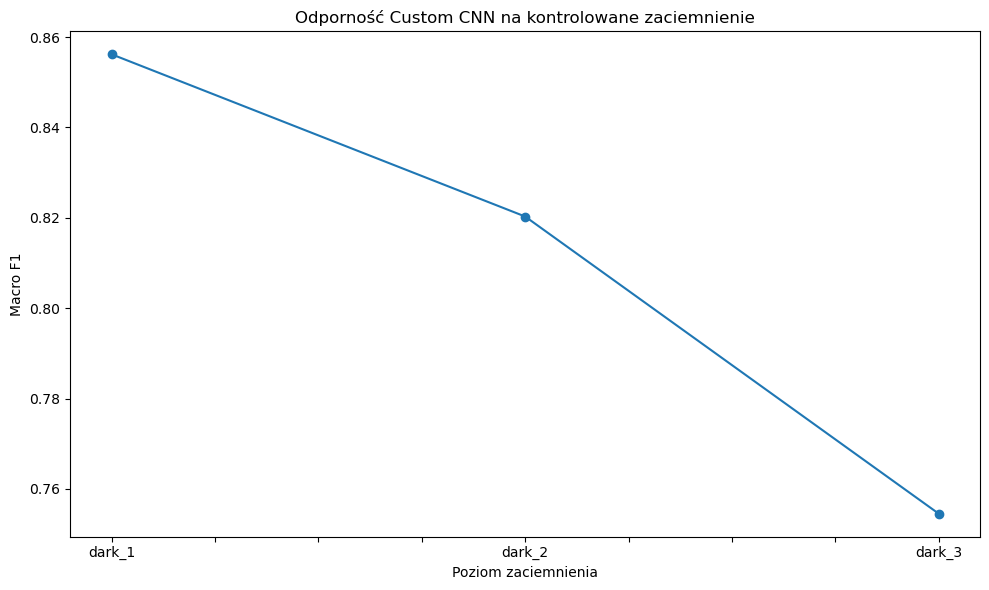

In [18]:
dark_plot = (
    dark_results_df.set_index(
        "variant"
    )[
        "macro_f1"
    ]
    .reindex(
        DARK_VARIANTS
    )
)


display(
    dark_plot
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


dark_plot.plot(
    marker="o",
    ax=ax,
)


ax.set_title(
    "Odporność Custom CNN "
    "na kontrolowane zaciemnienie"
)

ax.set_xlabel(
    "Poziom zaciemnienia"
)

ax.set_ylabel(
    "Macro F1"
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "03_custom_cnn_dark_robustness.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

In [19]:
screening_summary = pd.DataFrame([
    {
        "model":
            "CustomCNN",

        "parameters":
            total_params,

        "training_time_seconds":
            history[
                "training_time_seconds"
            ],

        "standard_accuracy":
            standard_validation[
                "accuracy"
            ],

        "standard_macro_precision":
            standard_validation[
                "macro_precision"
            ],

        "standard_macro_recall":
            standard_validation[
                "macro_recall"
            ],

        "standard_macro_f1":
            standard_validation[
                "macro_f1"
            ],

        "mean_dark_macro_f1":
            mean_dark_macro_f1,

        "mean_dark_accuracy":
            mean_dark_accuracy,

        "dark3_macro_f1":
            dark3_macro_f1,

        "f1_drop_to_dark3":
            f1_drop_to_dark3,
    }
])


display(
    screening_summary
)


screening_summary.to_csv(
    METRICS_DIR
    / "custom_cnn_screening_final_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

,model,parameters,training_time_seconds,standard_accuracy,standard_macro_precision,standard_macro_recall,standard_macro_f1,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,f1_drop_to_dark3
0,CustomCNN,413020,16580.48755,0.885748,0.855705,0.897944,0.854669,0.810335,0.845807,0.754517,0.100152
